In [32]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam, Adadelta

rng = np.random.default_rng(32)
tf.keras.utils.set_random_seed(32)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [33]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "dv0_withoutstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [34]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 64 … 77


In [35]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (99996, 82)
Global Participant_ID range: 6 … 77


In [36]:
df_all

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747823631000,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747823631200,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747823631400,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747823631600,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747823631800,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99991,20621,1750719007400,1647,1625,1610,1610,1592,1569,1580,1569,...,7.7,water,n,0,0,False,False,5,0.0,0
99992,20622,1750719007600,1637,1611,1592,1596,1570,1569,1575,1569,...,7.7,water,n,0,0,False,False,5,0.0,0
99993,20623,1750719007800,1607,1607,1592,1595,1568,1567,1560,1566,...,7.7,water,n,0,0,False,False,5,0.0,0
99994,20624,1750719008000,1602,1593,1586,1585,1568,1562,1560,1560,...,7.7,water,n,0,0,False,False,5,0.0,0


In [37]:
df = df_all

In [38]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [39]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 8                                   # 1 = ragged, >1 = padded


In [40]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# # ====================================================================
# df = df[df["Label"] == 1]                        # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:                                # ← drop empty sip
#         skip_count += 1
#         continue
#     X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
#     y.append(dV)

# y = np.asarray(y, np.float32)
# X = np.array(X, dtype=object)   # each element is still a (T,64) array
# print(f"Total sips kept : {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", y.min(), "max:", y.max())

In [41]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # ====================================================================

# df = df[df["Label"] == 1]                        # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip, std_dev=0.01):
#     """Add Gaussian noise to the sip (T, 64)."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     return sip + noise

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- You control this threshold: sips longer than this will be augmented
# AUGMENT_IF_LONGER_THAN = 15  # You can change this

# # --- Main data list
# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     X.append(sip_frames)
#     y.append(dV)

#     # Augment only if sip is long
#     if T > AUGMENT_IF_LONGER_THAN:
#         # 1. Add Gaussian noise
#         noisy_sip = add_gaussian_noise(sip_frames)
#         X.append(noisy_sip)
#         y.append(dV)

#         # 2. Flip horizontally
#         flipped_sip = flip_horizontal(sip_frames)
#         X.append(flipped_sip)
#         y.append(dV)
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))


In [42]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # ====================================================================


# df = df[df["Label"] == 1]  # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip, std_dev=40):
#     """Add Gaussian noise to the sip (T, 64)."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     return sip + noise

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- Thresholds you control
# AUGMENT_IF_LONGER_THAN = 15           # Regular augmentation if T > this
# MORE_AUGMENT_IF_LONGER_THAN = 20      # Extra augmentation if T > this
# NUM_EXTRA_NOISY_COPIES = 5            # Number of additional noise versions for long sips
# NUM_EXTRA_NOISY_COPIES_2 =3
# MORE_AUGMENT_IF_LONGER_THAN_2= 34
# # --- Main data list
# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     # Original sip
#     X.append(sip_frames)
#     y.append(dV)

#     # Moderate-length sip → 1 noise + 1 flip
#     if T > AUGMENT_IF_LONGER_THAN:
#         noisy_sip = add_gaussian_noise(sip_frames)
#         X.append(noisy_sip)
#         y.append(dV)

#         flipped_sip = flip_horizontal(sip_frames)
#         X.append(flipped_sip)
#         y.append(dV)

#     # Extra-long sip → multiple noise augmentations
#     if T > MORE_AUGMENT_IF_LONGER_THAN:
#         for _ in range(NUM_EXTRA_NOISY_COPIES):
#             noisy_version = add_gaussian_noise(sip_frames)
#             X.append(noisy_version)
#             y.append(dV)
#     if T > MORE_AUGMENT_IF_LONGER_THAN_2:
#         for _ in range(NUM_EXTRA_NOISY_COPIES_2):
#             noisy_version = add_gaussian_noise(sip_frames)
#             X.append(noisy_version)
#             y.append(dV)        

# # Final conversion to array
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))



In [43]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# ====================================================================


df = df[df["Label"] == 1]  # keep only annotated frames

feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# --- Augmentation Functions ---
def add_gaussian_noise(sip, std_dev=40):
    """Add Gaussian noise to the sip (T, 64), ensuring non-negative values."""
    noise = np.random.normal(60, std_dev, sip.shape)
    noisy_sip = sip + noise
    return np.clip(noisy_sip, a_min=0.0, a_max=None)  # Ensure no negative values


def flip_horizontal(sip):
    """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

# --- Thresholds you control
AUGMENT_IF_LONGER_THAN = 25           # Regular augmentation if T > this
MORE_AUGMENT_IF_LONGER_THAN = 25      # Extra augmentation if T > this
NUM_EXTRA_NOISY_COPIES = 10            # Number of additional noise versions for long sips
NUM_EXTRA_NOISY_COPIES_2 =5
MORE_AUGMENT_IF_LONGER_THAN_2= 34
# --- Main data list
X, y = [], []
y_before_aug = []   # NEW: to store dV values before augmentation

skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:
        skip_count += 1
        continue

    sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
    T = len(sip_frames)

    # Original sip
    X.append(sip_frames)
    y.append(dV)
    y_before_aug.append(dV)
    # Moderate-length sip → 1 noise + 1 flip
    if dV > AUGMENT_IF_LONGER_THAN:
        noisy_sip = add_gaussian_noise(sip_frames)
        X.append(noisy_sip)
        y.append(dV)

        flipped_sip = flip_horizontal(sip_frames)
        X.append(flipped_sip)
        y.append(dV)
    if dV < 55 and 45 < dV :
        for _ in range(NUM_EXTRA_NOISY_COPIES_2):
            noisy_version = add_gaussian_noise(sip_frames)
            X.append(noisy_version)
            y.append(dV)     
    if dV < 75 and 65 < dV :
        for _ in range(NUM_EXTRA_NOISY_COPIES_2):
            noisy_version = add_gaussian_noise(sip_frames)
            X.append(noisy_version)
            y.append(dV) 
    if dV < 95 and 85 < dV :
        for _ in range(24):
            noisy_version = add_gaussian_noise(sip_frames)
            X.append(noisy_version)
            y.append(dV) 
    if dV < 85 and 80 < dV :
        for _ in range(7):
            noisy_version = add_gaussian_noise(sip_frames)
            X.append(noisy_version)
            y.append(dV) 
    # Extra-long sip → multiple noise augmentations
    # if dV > MORE_AUGMENT_IF_LONGER_THAN:
    #     for _ in range(NUM_EXTRA_NOISY_COPIES):
    #         noisy_version = add_gaussian_noise(sip_frames)
    #         X.append(noisy_version)
    #         y.append(dV)
    # if dV > MORE_AUGMENT_IF_LONGER_THAN_2:
    #     for _ in range(NUM_EXTRA_NOISY_COPIES_2):
    #         noisy_version = add_gaussian_noise(sip_frames)
    #         X.append(noisy_version)
    #         y.append(dV)        
    if dV < 5 :
        for _ in range(3):
            noisy_version = add_gaussian_noise(sip_frames)
            X.append(noisy_version)
            y.append(dV) 
    if 40 < dV :
        for _ in range(4):
            noisy_version = add_gaussian_noise(sip_frames)
            X.append(noisy_version)
            y.append(dV) 
# Final conversion to array
X = np.array(X, dtype=object)   # each sip is still (T, 64)
y = np.array(y, dtype=np.float32)
y_before_aug = np.array(y_before_aug, dtype=np.float32)

print(f"Total sips kept (including augmented): {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", min(y), "max:", max(y))



Total sips kept (including augmented): 1450
Zero-volume skipped : 2
Label stats  → min: 1.4691479 max: 160.2


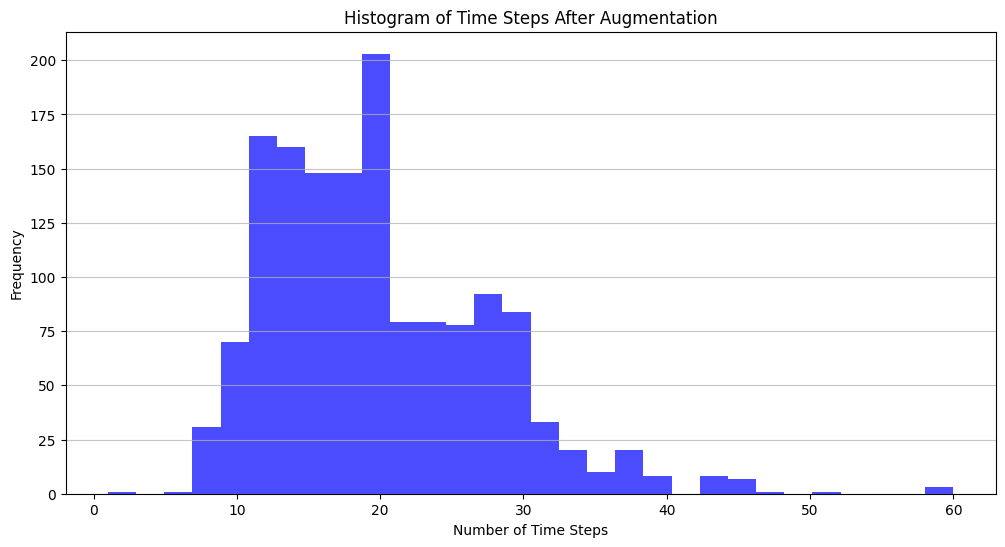

In [44]:
import matplotlib.pyplot as plt

# Get time step lengths for all sips
time_steps = [sip.shape[0] for sip in X]  # X is your final data after augmentation

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(time_steps, bins=30, alpha=0.7, color='blue')
plt.title('Histogram of Time Steps After Augmentation')
plt.xlabel('Number of Time Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


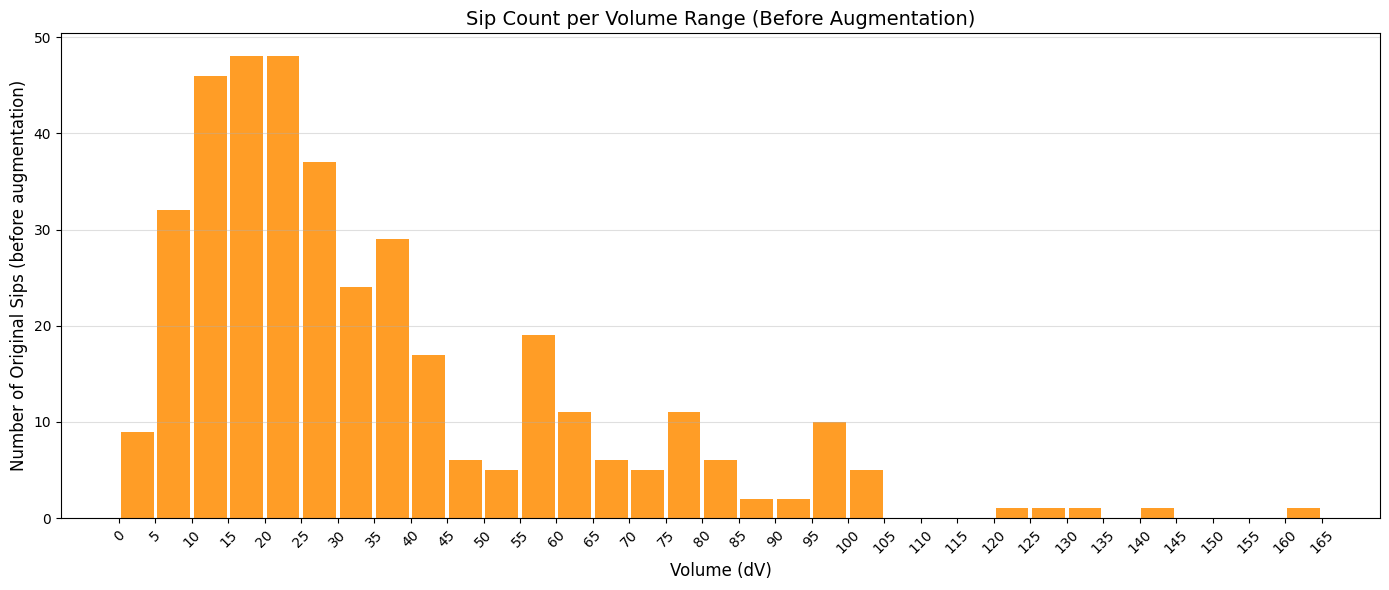

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Create a fresh list for original (pre-augmentation) volumes
original_volumes = []

for _, g in df.groupby(["Participant_ID", "sip_id"], sort=False):
    dV = float(g["dV"].iloc[0])
    if dV == 0.0:
        continue
    original_volumes.append(dV)  # Only original sips, no augmentation

# Convert to NumPy array
original_volumes = np.array(original_volumes)

# --- Parameters ---
bin_width = 5  # mL
min_vol = int(np.floor(min(original_volumes) / bin_width) * bin_width)
max_vol = int(np.ceil(max(original_volumes) / bin_width) * bin_width)

# Create bins (e.g., [0, 5, 10, ..., 100])
volume_bins = np.arange(min_vol, max_vol + bin_width, bin_width)

# Digitize original_volumes into bins
bin_indices = np.digitize(original_volumes, volume_bins)
bin_counts = [0] * (len(volume_bins) - 1)

# Count how many original sips fall into each bin
for idx in bin_indices:
    if 1 <= idx < len(volume_bins):
        bin_counts[idx - 1] += 1

# Bin centers
bin_centers = [(volume_bins[i] + volume_bins[i + 1]) / 2 for i in range(len(volume_bins) - 1)]

# Create DataFrame for export
df_export = pd.DataFrame({
    'Volume_Range': [f"{volume_bins[i]}-{volume_bins[i+1]}" for i in range(len(volume_bins)-1)],
    'Bin_Center': bin_centers,
    'Sip_Count': bin_counts
})

# Export to Excel
df_export.to_excel('sip_volume_distribution_before_augmentation.xlsx', index=False)

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.bar(bin_centers, bin_counts, width=bin_width * 0.9, color='darkorange', alpha=0.85)
plt.xlabel('Volume (dV)', fontsize=12)
plt.ylabel('Number of Original Sips (before augmentation)', fontsize=12)
plt.title('Sip Count per Volume Range (Before Augmentation)', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.xticks(np.arange(min_vol, max_vol + 1, bin_width), rotation=45)
plt.tight_layout()
plt.show()


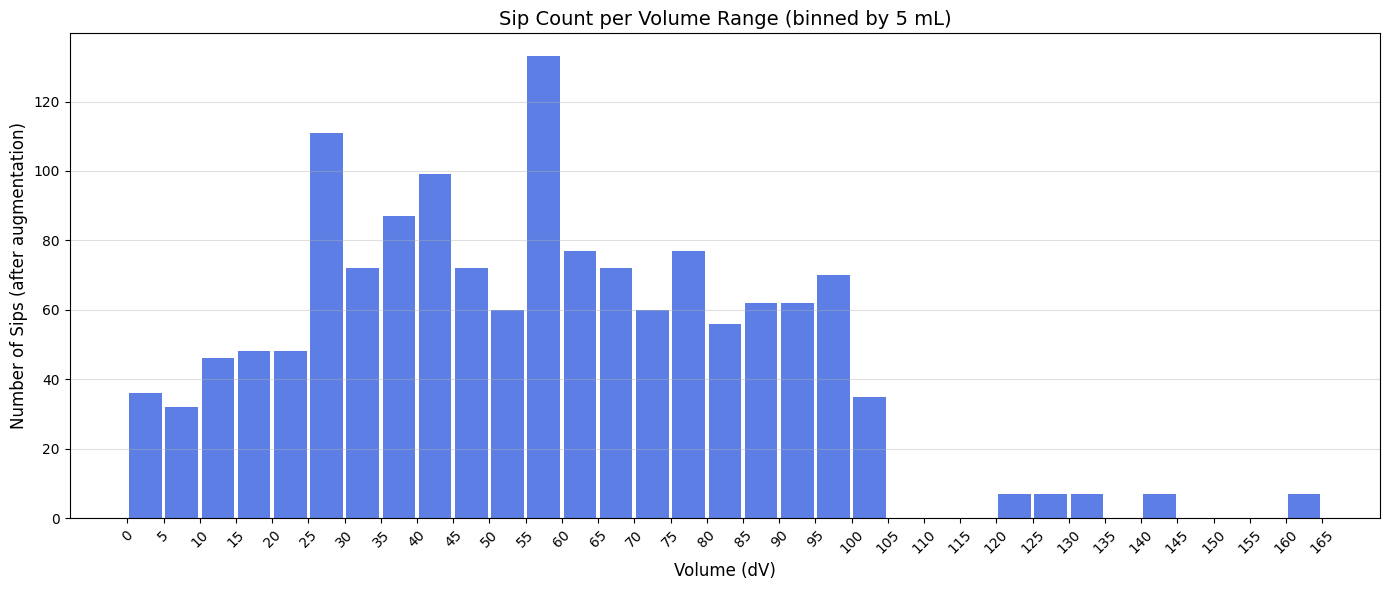

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Parameters ---
bin_width = 5  # mL
min_vol = int(np.floor(min(y) / bin_width) * bin_width)
max_vol = int(np.ceil(max(y) / bin_width) * bin_width)

# Create bins (e.g., [0, 5, 10, ..., 100])
volume_bins = np.arange(min_vol, max_vol + bin_width, bin_width)

# Digitize y into bins
bin_indices = np.digitize(y, volume_bins)  # assigns bin index
bin_counts = [0] * (len(volume_bins) - 1)

# Count how many sips fall into each bin
for idx in bin_indices:
    if 1 <= idx < len(volume_bins):  # skip out-of-range
        bin_counts[idx - 1] += 1

# Bin labels: midpoint of each bin (e.g., 2.5, 7.5, ...)
bin_centers = [(volume_bins[i] + volume_bins[i + 1]) / 2 for i in range(len(volume_bins) - 1)]

# Create DataFrame for export
df_export = pd.DataFrame({
    'Volume_Range': [f"{volume_bins[i]}-{volume_bins[i+1]}" for i in range(len(volume_bins)-1)],
    'Bin_Center': bin_centers,
    'Sip_Count': bin_counts
})

# Export to Excel
df_export.to_excel('sip_volume_distribution_after_augmentation.xlsx', index=False)

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.bar(bin_centers, bin_counts, width=bin_width * 0.9, color='royalblue', alpha=0.85)
plt.xlabel('Volume (dV)', fontsize=12)
plt.ylabel('Number of Sips (after augmentation)', fontsize=12)
plt.title('Sip Count per Volume Range (binned by 5 mL)', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.xticks(np.arange(min_vol, max_vol + 1, bin_width), rotation=45)
plt.tight_layout()
plt.show()


In [47]:
X[:1]

array([array([[2487.,  165.,  348., ...,  364.,  330., 1817.],
              [2487.,  165.,  348., ...,  364.,  330., 1817.],
              [ 265.,  200.,  234., ...,  364.,  352., 1817.],
              ...,
              [ 304., 2267., 2300., ...,  331., 1449., 1140.],
              [ 299., 2267., 2300., ...,  352.,  352., 1151.],
              [ 295., 2280., 2300., ...,  352., 1449., 1151.]], dtype=float32)],
      dtype=object)

In [48]:
print(type(X))          # <class 'numpy.ndarray'>
print(X.shape)          # (number,)

print(type(X[0]))       # <class 'numpy.ndarray'>
print(X[0].shape)       # (rows, columns)

<class 'numpy.ndarray'>
(1450,)
<class 'numpy.ndarray'>
(26, 64)


In [49]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split1 = int(.64 * len(X))          # 64 % train
split2 = int(.80 * len(X))          # next 16 % val
X_train, y_train = X[idx[:split1]], y[idx[:split1]]
X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)


Train 928 Val 232  Test 290


In [50]:
# X_train


In [51]:
# y_train

In [52]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  



In [53]:
# X_train

In [54]:
# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [55]:
train_ds

<_PaddedBatchDataset element_spec=(TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [56]:
# for batch in train_ds.take(1):
#     x_batch, y_batch = batch
#     print("x_batch shape:", x_batch.shape)
#     print("y_batch shape:", y_batch.shape)
#     print("x_batch:", x_batch.numpy())
#     print("y_batch:", y_batch.numpy())

In [57]:
# ====================================================================
# 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# ====================================================================
inp = tf.keras.Input(shape=(None, 64))
x = TCN(nb_filters=128,
        kernel_size=3,
        dilations=[1,2,4,8,16,32,64],   # ~64-time-step field
        dropout_rate=0.1,
        return_sequences=False)(inp)
out = tf.keras.layers.Dense(1)(x)          # ← LINEAR output
model = tf.keras.Model(inp, out)

model.compile(
    optimizer=Adagrad(learning_rate=0.01),
    loss="mae"                             # MAE is more robust
)
model.summary()

steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# weights = (y_train / y_train.max()) ** 0.5  
cb = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss', patience=50, restore_best_weights=True)
model.fit(
    train_ds,
    epochs=200,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,        # ⬅ use VALIDATION set
    validation_steps=val_steps,
    verbose=1,
    # sample_weight=weights,
    callbacks=[cb]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 128)            │       673,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,793 (2.57 MB)

 Trainable params: 673,793 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 74.9611 - val_loss: 15.7439
Epoch 2/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 16.9813 - val_loss: 13.4569
Epoch 3/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 15.5708 - val_loss: 13.1441
Epoch 4/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 15.0601 - val_loss: 12.6349
Epoch 5/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 13.6791 - val_loss: 14.1660
Epoch 6/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 13.9897 - val_loss: 12.0919
Epoch 7/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 11.5302 - val_loss: 10.9297
Epoch 8/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 10.9140 - val_loss: 11.6803
Epoch 9/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 11.2464 - val_loss: 12.1448
Epoch 10/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 10.4727 - val_loss: 16.0943
Epoch 11/200
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 11.0931 - val_loss: 11.4480
Epoch 12

In [58]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_test])
# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [59]:
# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

non_zero = y_test != 0
rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_test)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))


Evaluation on 290 test sips
  MSE   : 178.6043
  RMSE  : 13.3643
  R²    : 0.7802
  RMSPE : 82.29%

First 50 predictions:
     Actual dV  Predicted dV
0    59.700001     54.503201
1    39.781746     77.387314
2    29.400000     35.309006
3    19.392752     20.806881
4     6.660137     25.433233
5    78.354553     70.150856
6    59.523811     47.232258
7    40.000000     37.874001
8    19.841270     39.997021
9    68.857140     64.897301
10   68.285713     55.021847
11   78.354553     72.773430
12    1.469148     14.028693
13   59.523811     56.467152
14   30.852106     21.461285
15   54.299999     51.714539
16   24.100000     36.390247
17   12.747036     17.824045
18   27.717924     21.629702
19   91.500000     84.288307
20   85.699997     76.134071
21   99.206352     89.253311
22   25.465231     27.117466
23   46.500000     32.670525
24   10.246305     22.716602
25   68.500000     64.876534
26   76.190475     75.253822
27   28.403526     41.069630
28   54.299999     52.358551
29   23

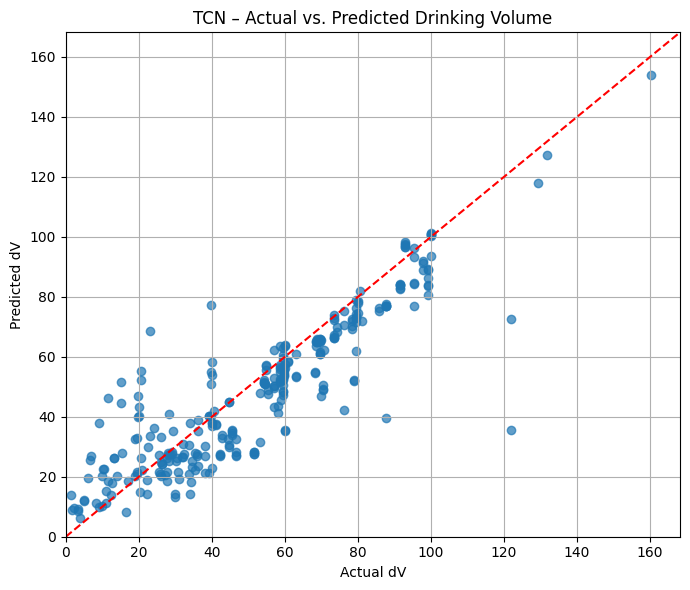

In [60]:
# ====================================================================
# 8. scatter plot
# ====================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
plt.title("TCN – Actual vs. Predicted Drinking Volume")
plt.grid(True); plt.tight_layout(); plt.show()

In [61]:
# print("First 5 log targets  :", y_train_s[:5])
# print("First 5 raw targets  :", y_train[:5])

# # after one epoch
# raw_pred = np.expm1(model.predict(X_val[:3])[...,0])
# print("First 3 un-scaled predictions:", raw_pred)

In [62]:
print("train  min / max (ml):", y_train.min(), y_train.max())
print("train_s min / max (log):", y_train_s.min(), y_train_s.max())

# quick expectation check:  ln(1+160) ≈ 5.08
#                           ln(1+  5) ≈ 1.79

train  min / max (ml): 1.4691479 160.2
train_s min / max (log): -1.8635402 3.4759934
